In [1]:
import yaml
from pathlib import Path

config_path = Path('../config/config.yaml')
if not config_path.exists():
    raise FileNotFoundError(
        'config/config.yaml not found. '
        'Copy config/config.template.yaml to config/config.yaml and fill in your paths.')

with open(config_path) as f:
    cfg = yaml.safe_load(f)

# unpack just for convenience
BASE_DIR       = cfg["data"]["base_dir"]
GEOJSON_PATH   = cfg["data"]["geojson_path"]
SUMMARY_CSV    = cfg["output"]["summary_csv"]
FIGURES_DIR    = cfg["output"]["figures_dir"]

WET_THRESHOLD  = cfg["analysis"]["wet_threshold"]
LOWER_MONTH    = cfg["analysis"]["lower_month"]
HIGHER_MONTH   = cfg["analysis"]["higher_month"]
DELT           = cfg["analysis"]["delT"]
TAU            = cfg["analysis"]["tau"]
LEN_WET        = cfg["analysis"]["len_wet"]
METEO_WINDOW   = cfg["analysis"]["meteo_window"]

In [2]:
#improts 

import sys
sys.path.insert(0, "..")

import numpy as np
import iris
from iris.time import PartialDateTime

from EventCoincidenceAnalysis.functions.event_detection import flag_wet_events, process_timeseries
from EventCoincidenceAnalysis.functions.eca_core import EventCoincidence, calculate_ECA_30y
from EventCoincidenceAnalysis.functions.statistics import binomial_Kt, binomial_Kp, decompose_years_30y
from EventCoincidenceAnalysis.functions.thresholds import get_percentile, get_value_from_percentile
from EventCoincidenceAnalysis.functions.iris_utils import add_yyyymmdd
from EventCoincidenceAnalysis.functions.plotting import plot_wales_case_study, plot_regional_ensemble_agreement, PERIOD_TITLE

In [3]:
# region and ensemble dicts
regions = {'East_Midlands': ['East Midlands'],
           'East_Scotland': ['East Scotland'],
           'East_of_England': ['East of England'],
           'North_East_England': ['North East England'],
           'North_Scotland': ['North Scotland'],
           'North_West_England': ['North West England'],
           'Northern_Ireland': ['Northern Ireland'],
           'South_East_England': ['South East England'],
           'South_West_England': ['South West England'],
           'Wales' : ['Wales'],
           'West_Midlands': ['West Midlands'],
           'West_Scotland': ['West Scotland'],
           'Yorkshire_and_Humber': ['Yorkshire and Humber'],}

ensembles_dict = {'0000' : ['0000'],
             '1113' : ['1113'],
             '1554' : ['1554'],
             '1649' : ['1649'],
             '1843' : ['1843'],
             '1935' : ['1935'],
             '2123' : ['2123'],
             '2242' : ['2242'],
             '2305' : ['2305'],
             '2335' : ['2335'],
             '2491' : ['2491'],
             '2868' : ['2868']}

# Wales case study (4-panel plot)

/home/users/elena.dauster/.conda/envs/ECA/lib/python3.12/site-packages/iris/common/mixin.py:212: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


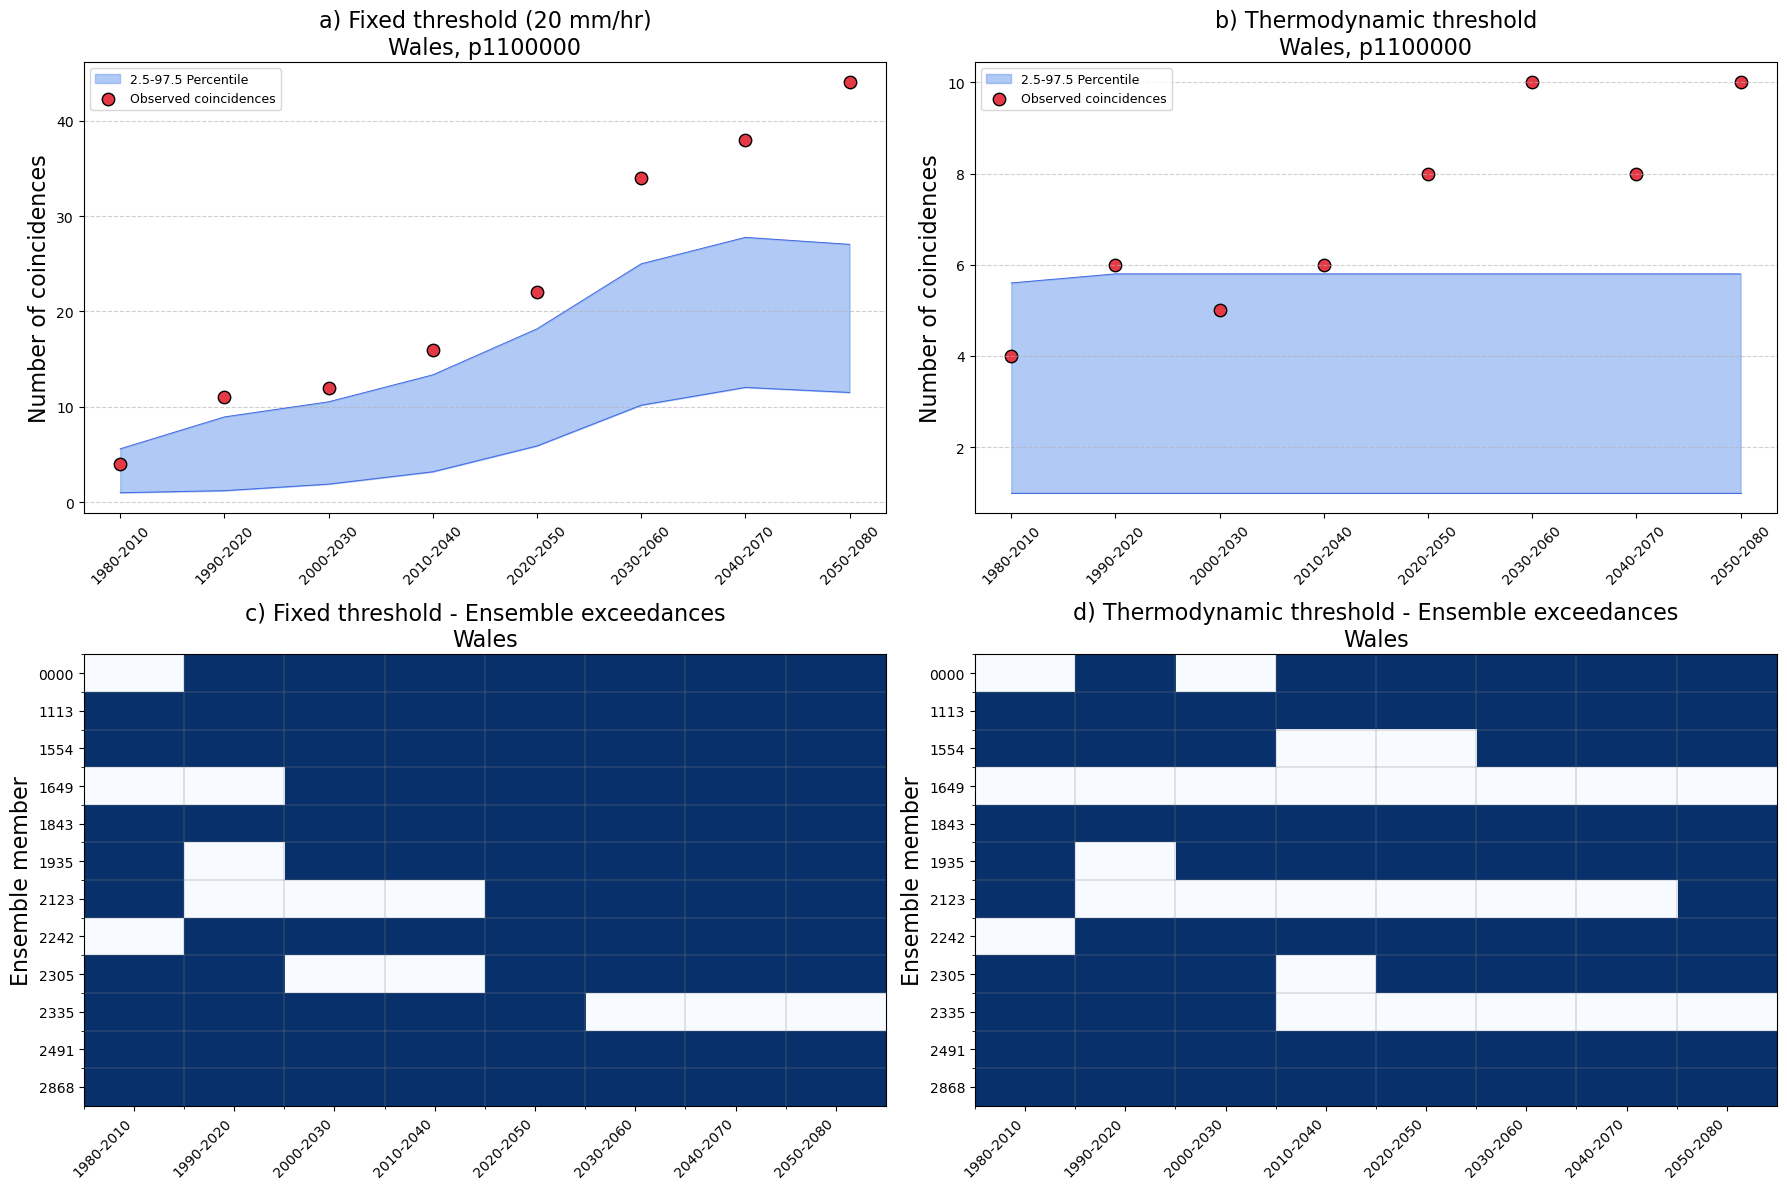

In [4]:
# all filepats are from BASE_DIR, no hardcoded paths
fig = plot_wales_case_study(
    base_dir=BASE_DIR,
    region_code='Wales',
    ensemble='0000',
    ensembles_dict = ensembles_dict,
    wet_threshold=WET_THRESHOLD,
    lower_month=LOWER_MONTH,
    higher_month=HIGHER_MONTH,
    delT=DELT,
    tau=TAU,
    len_wet=LEN_WET,
    meteo_window=METEO_WINDOW,)

fig.savefig(f"{FIGURES_DIR}/wales_case_study.png", dpi=150, bbox_inches="tight")

# regional loop (all regions x all ensembles)

In [5]:
# nitialise results dicts for both fixed and thermodynamic thresholds
num_periods = len(PERIOD_TITLE)
results_fixed = {region_code: {ens: [] for ens in ensembles_dict} for region_code in regions.keys()}
results_thermo = {region_code: {ens: [] for ens in ensembles_dict} for region_code in regions.keys()}

for region_code in regions.keys():
    print(f"Processing region: {region_code}")
    
    for ensemble in ensembles_dict:
        try:
            cube = iris.load(f'{BASE_DIR}/{region_code}/p110{ensemble}_{region_code}.nc')[0]
            month_range = iris.Constraint(
                time=lambda cell: PartialDateTime(month=LOWER_MONTH) <= cell.point <= PartialDateTime(month=HIGHER_MONTH))
            month_extraction_cube = cube.extract(month_range)

            climatology = {f'cube_{yr}': decompose_years_30y(month_extraction_cube)[j].data for j, yr in enumerate(PERIOD_TITLE)}

            # --- fuxed threshold ---
            wet_timeseries_fixed = [flag_wet_events(climatology[key], LEN_WET, WET_THRESHOLD) for key in climatology]
            period_ECA_fixed = calculate_ECA_30y(wet_timeseries_fixed, wet_timeseries_fixed, delT=DELT, tau=TAU)
            N_trig_fixed = [eca.get_coincidences[1] for eca in period_ECA_fixed]

            for period_index in range(num_periods):
                seriesA = wet_timeseries_fixed[period_index]
                binom_probs = []
                cumsum = 0
                KT = 0
                while cumsum < 1 - 1e-6:
                    p = binomial_Kt(seriesA, seriesA, KT, delT=DELT, tau=TAU)
                    binom_probs.append(p)
                    cumsum += p
                    KT += 1
                y_values = np.arange(1, len(binom_probs) + 1)
                cumulative_probs = np.cumsum(binom_probs)
                p_99 = np.interp(0.975, cumulative_probs, y_values)
                results_fixed[region_code][ensemble].append(1 if N_trig_fixed[period_index] > p_99 else 0)

            # --- thermo threshold ---
            percentile_1980_10 = get_percentile(WET_THRESHOLD, climatology['cube_1980-2010'])
            wet_thresholds = [get_value_from_percentile(percentile_1980_10, climatology[f'cube_{yr}']) for yr in PERIOD_TITLE]
            wet_timeseries_thermo = [flag_wet_events(climatology[key], LEN_WET, wt) for key, wt in zip(climatology.keys(), wet_thresholds)]
            period_ECA_thermo = calculate_ECA_30y(wet_timeseries_thermo, wet_timeseries_thermo, delT=DELT, tau=TAU)
            N_trig_thermo = [eca.get_coincidences[1] for eca in period_ECA_thermo]

            for period_index in range(num_periods):
                seriesA = wet_timeseries_thermo[period_index]
                binom_probs = []
                cumsum = 0
                KT = 0
                while cumsum < 1 - 1e-6:
                    p = binomial_Kt(seriesA, seriesA, KT, delT=DELT, tau=TAU)
                    binom_probs.append(p)
                    cumsum += p
                    KT += 1
                y_values = np.arange(1, len(binom_probs) + 1)
                cumulative_probs = np.cumsum(binom_probs)
                p_99 = np.interp(0.975, cumulative_probs, y_values)
                results_thermo[region_code][ensemble].append(1 if N_trig_thermo[period_index] > p_99 else 0)

        except Exception as e:
            print(f"  Error processing ensemble {ensemble}: {e}")
            results_fixed[region_code][ensemble] = [0] * num_periods
            results_thermo[region_code][ensemble] = [0] * num_periods

Processing region: East_Midlands


/home/users/elena.dauster/.conda/envs/ECA/lib/python3.12/site-packages/iris/common/mixin.py:212: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


Processing region: East_Scotland
Processing region: East_of_England
Processing region: North_East_England
Processing region: North_Scotland
Processing region: North_West_England
Processing region: Northern_Ireland
Processing region: South_East_England
Processing region: South_West_England
Processing region: Wales
Processing region: West_Midlands
Processing region: West_Scotland
Processing region: Yorkshire_and_Humber


# save results and plot regional map

Saved summary to /home/users/elena.dauster/UKCI/outputs/summary_ECA_results.csv
                  Region  1980-2010 Fixed Threshold  \
0          East Midlands                          5   
1          East Scotland                          7   
2        East of England                          6   
3     North East England                          2   
4         North Scotland                          7   
5     North West England                          3   
6       Northern Ireland                          5   
7     South East England                         10   
8     South West England                         10   
9                  Wales                          9   
10         West Midlands                          5   
11         West Scotland                          6   
12  Yorkshire and Humber                          4   

    2050-2080 Fixed Threshold  2050-2080 Thermo Threshold  
0                           9                           7  
1                          12

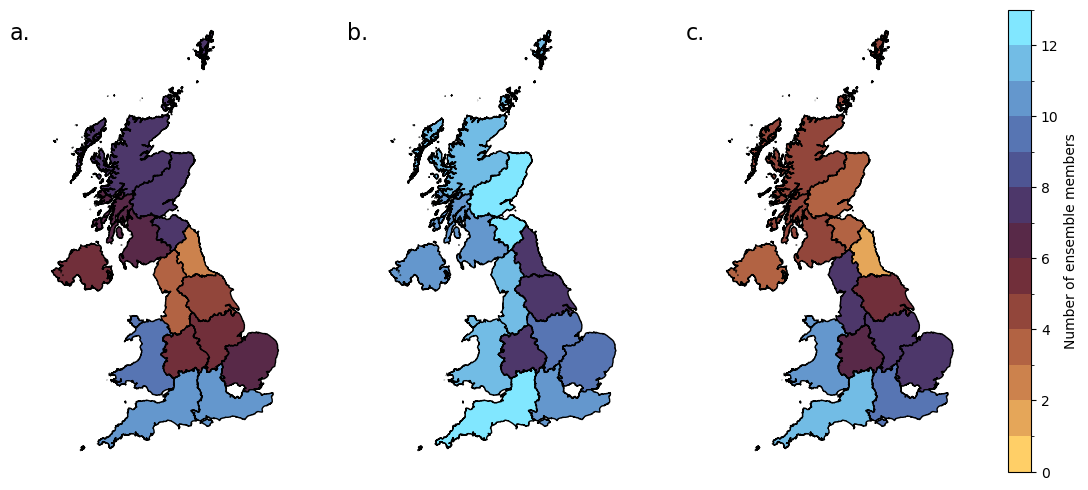

In [6]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from EventCoincidenceAnalysis.functions.plotting import plot_regional_ensemble_agreement

# buiold summary df
summary_data = {
    'Region': [],
    '1980-2010 Fixed Threshold': [],
    '2050-2080 Fixed Threshold': [],
    '2050-2080 Thermo Threshold': []}

for region_code, region_name_list in regions.items():
    summary_data['Region'].append(region_name_list[0])
    summary_data['1980-2010 Fixed Threshold'].append(sum(results_fixed[region_code][ens][0] for ens in ensembles_dict))
    summary_data['2050-2080 Fixed Threshold'].append(sum(results_fixed[region_code][ens][7] for ens in ensembles_dict))
    summary_data['2050-2080 Thermo Threshold'].append(sum(results_thermo[region_code][ens][7] for ens in ensembles_dict))

summary_df = pd.DataFrame(summary_data)

# sacve CSV
Path(FIGURES_DIR).mkdir(parents=True, exist_ok=True)
summary_df.to_csv(SUMMARY_CSV, index=False)
print(f"Saved summary to {SUMMARY_CSV}")
print(summary_df)

# load geodata and plot
regions_gdf = gpd.read_file(GEOJSON_PATH)
fig = plot_regional_ensemble_agreement(summary_df, regions_gdf)
fig.savefig(f"{FIGURES_DIR}/regional_ensemble_agreement.png", dpi=150, bbox_inches="tight")
plt.show()